In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Production mix disaggregation

In [11]:
production_mix = pd.read_excel('./DH production mix/four_category.xlsx', sheet_name='agg')
production_mix.index = pd.to_datetime(production_mix['month'].astype(str).str.strip(), format='%Y-%m')
production_mix.drop(columns=['month'], inplace=True)

In [12]:
priority_sources = ['Waste heat', 'Electricity', 'Biomass', 'Fossil fuel']
years = range(2021, 2026)
daily_df = pd.DataFrame()

frames = []

for yr in years:
    daily = pd.read_csv(
        f'./DH production mix/daily_{yr}.csv',
        parse_dates=['date']
    )
    daily = daily.set_index('date')
    daily_df = pd.concat([daily_df, daily[priority_sources]])

    # Sum source columns + total per calendar month
    agg = daily[priority_sources + ['daily_total_mwh']].resample('ME').sum()
    frames.append(agg)

# production_disagg = pd.concat(frames)   # stack all years
# production_disagg.index.name = 'month'
# production_disagg.index = production_disagg.index.strftime('%Y-%m')
# production_disagg = production_disagg.rename(columns={'daily_total_mwh': 'monthly_total_mwh'})

display(daily_df.head())

,Waste heat,Electricity,Biomass,Fossil fuel
date,,,,
2021-01-01,1831.322581,162.580645,788.082089,742.342874
2021-01-02,1831.322581,162.580645,788.082089,416.767460
2021-01-03,1831.322581,162.580645,788.082089,1051.228698
2021-01-04,1831.322581,162.580645,788.082089,1095.905450
2021-01-05,1831.322581,162.580645,788.082089,1096.418976


In [13]:
production_mix = production_mix.apply(pd.to_numeric)
production_mix['monthly_total_mwh'] = production_mix.sum(axis=1)
production_mix.index = production_mix.index.strftime('%Y-%m')
display(production_mix.head())

,Waste heat,Electricity,Biomass,Fossil fuel,monthly_total_mwh
month,,,,,
2021-01,56771,5040,24228.0,26654,112693.0
2021-02,49186,4760,19487.0,20229,93662.0
2021-03,55311,401,13333.0,2577,71622.0
2021-04,49095,610,10910.0,1707,62322.0
2021-05,34248,418,756.0,3360,38782.0


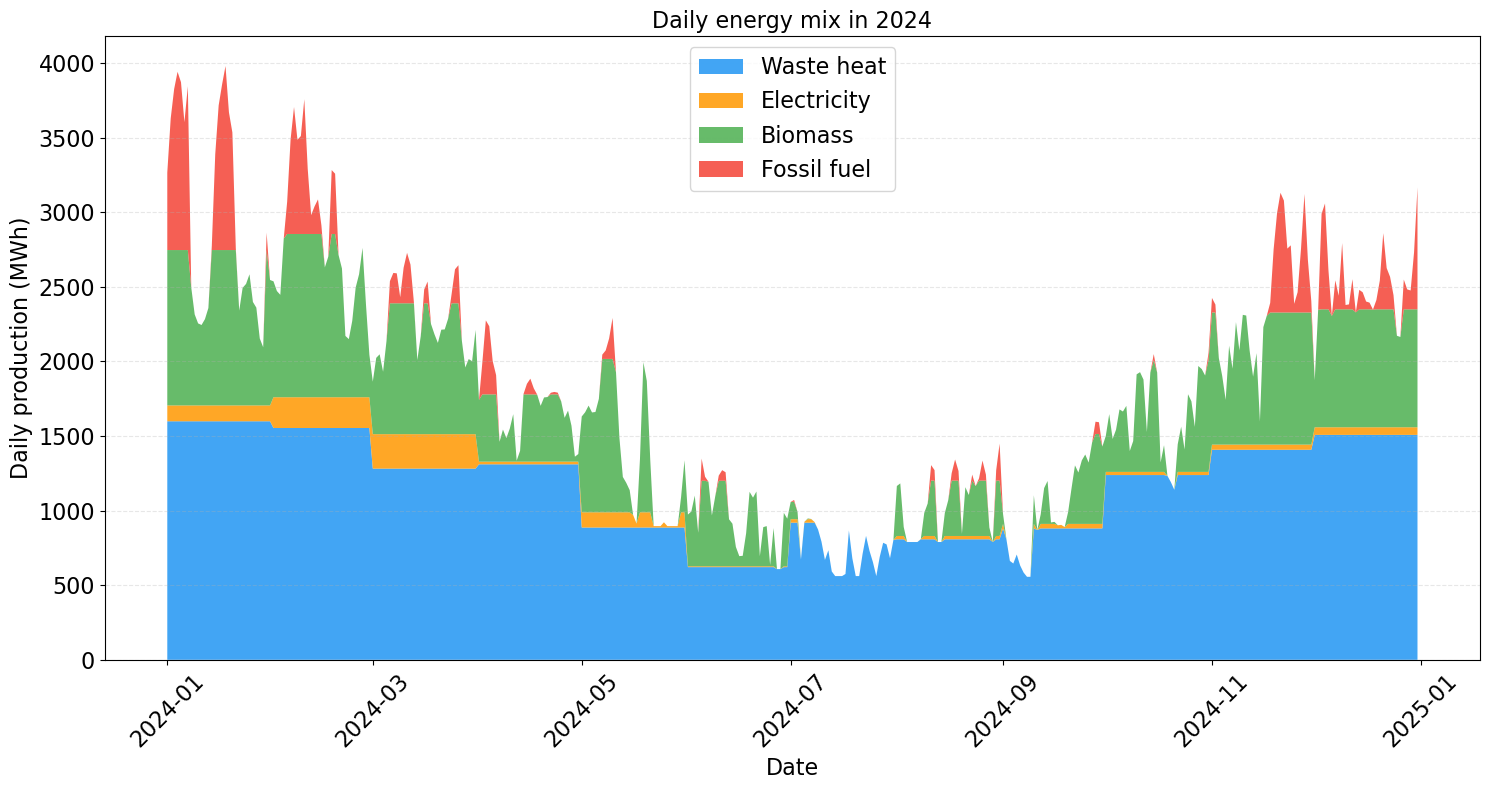

In [14]:
start_date = "2024-01-01"
end_date = "2024-12-31"

plot_df = daily_df[
    (daily_df.index >= start_date) &
    (daily_df.index <= end_date)
].copy()

energy_cols = ['Waste heat', 'Electricity', 'Biomass', 'Fossil fuel']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

plot_df['daily_total_mwh'] = plot_df.sum(axis=1)
plot_df['date_'] = plot_df.index
plot_df = plot_df.sort_values("date_")

plt.figure(figsize=(15, 8))

# Use stacked area plot for continuous daily composition with your colors
plt.stackplot(
    plot_df.index,
    [plot_df[col] for col in energy_cols],
    labels=energy_cols,
    colors=colors,            # <--- Pass your custom colors here
    alpha=0.85
)

# Plot a clean dashed line for the total daily production
# plt.plot(
#     plot_df.index,
#     plot_df["daily_total_mwh"],
#     color="black",
#     linestyle="--",
#     linewidth=1.2,
#     label="Total daily production"
# )

plt.xlabel("Date", fontsize=16)
plt.ylabel("Daily production (MWh)", fontsize=16)
plt.title(f"Daily energy mix in 2024", fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16, rotation=45)
plt.legend(loc="best", fontsize=16)
plt.grid(True, axis="y", alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("./figs/daily_stacked_area.png", dpi=300)
plt.show()

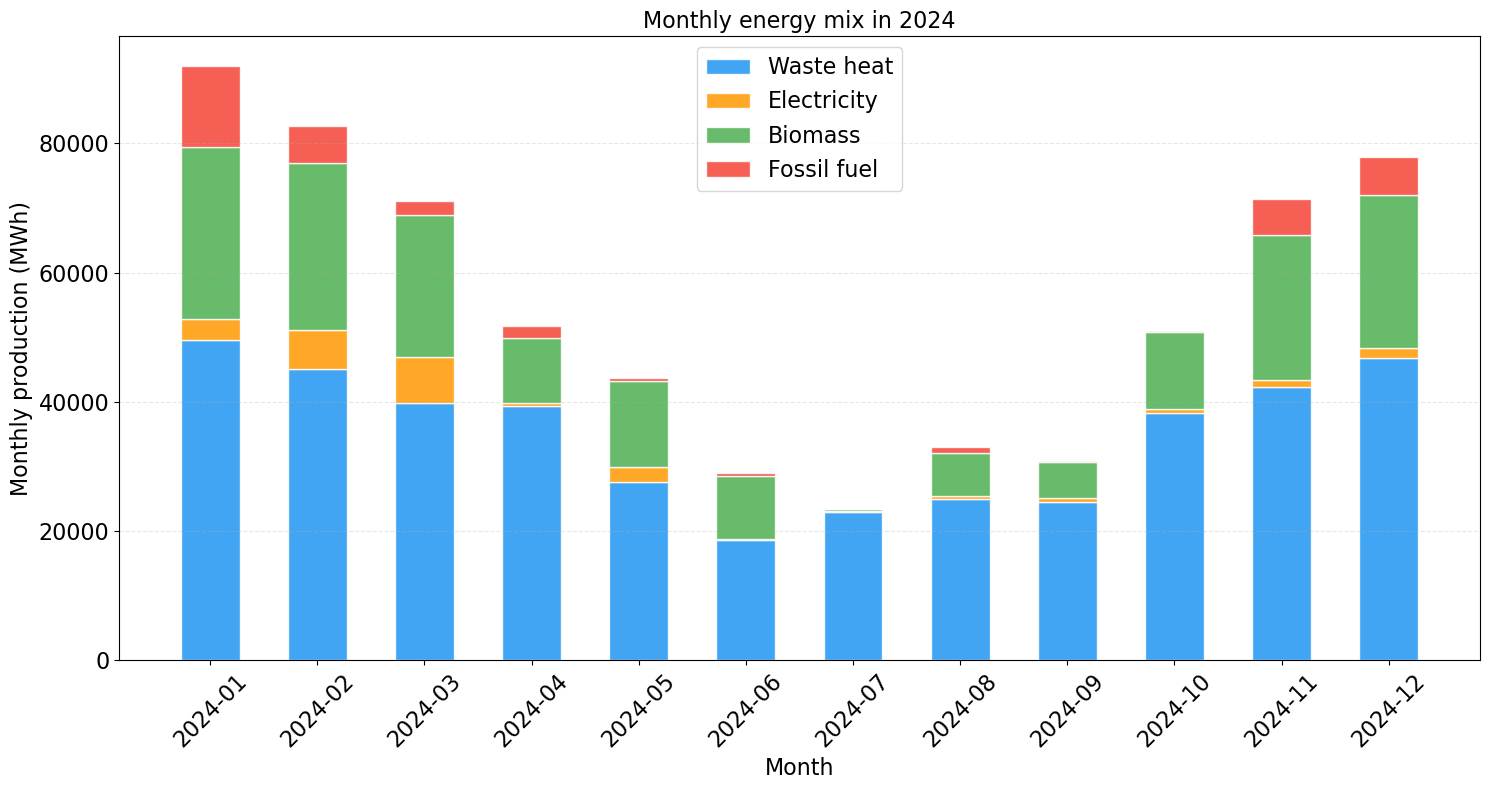

In [15]:
plot_df = production_mix[
    (production_mix.index >= start_date[:7]) &
    (production_mix.index <= end_date[:7])
].copy()

energy_cols = ['Waste heat', 'Electricity', 'Biomass', 'Fossil fuel']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

plt.figure(figsize=(15, 8))
bottom = np.zeros(len(plot_df))
for i, col in enumerate(energy_cols):
    plt.bar(
        plot_df.index,
        plot_df[col],
        bottom=bottom,
        label=col,
        color=colors[i],
        edgecolor='white',
        width=0.55,
        alpha=0.85
    )
    bottom += plot_df[col]
# Total line
# plt.plot(
#     plot_df.index,
#     plot_df['monthly_total_mwh'],
#     color='black',
#     linestyle='--',
#     marker='o',
#     linewidth=1.5,
#     label='Total monthly production'
# )
plt.xlabel('Month', fontsize=16)
plt.ylabel('Monthly production (MWh)', fontsize=16)
plt.title('Monthly energy mix in 2024', fontsize=16)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=16)
plt.tight_layout()
plt.savefig('./figs/monthly_stacked_bar.png', dpi=300)

Results analysis

# Why TES Secondary Temperatures Look "Weird" — Root Cause Analysis

## System Architecture (as modelled)

The intended physical layout is a **series circuit**:

```
Primary DH network
        │
    [HEX] ──► T_sec_supply_HEX  (hot water leaving HEX)
        │
     [TES tank]  ──► T_out_tank  (water leaving tank, at T_water)
        │
   [Building load]
        │
    T_sec_return  (cool return water)
        │
    [HEX secondary inlet] ←──────────────────────────────┘
```

Flow direction: HEX heats → tank stores/releases → building consumes → return to HEX.

---

## Issue 1 — The T_sec_supply Column is Set to T_water *Before* the Hour Starts

In [run_simulation.py](file:///home/yangzhe/myprojects/EIA_2026/simulation/run_simulation.py#L226-L228), at the start of each TES hour:

```python
# Series circuit calculations
T_sec_supply = T_water_current        # ← snapshot of T_water at the START of this hour
T_sec_return = compute_secondary_return_temperature(
    Q_demand_building, T_sec_supply, m_dot_sec=m_dot_sec)
T_sec_inlet  = T_sec_return
```

`T_water_current` was captured *before* the tank is stepped (line 207).  
After the 60 sub-steps the tank is advanced and `T_water_val = tank.T_water` (line 279) reflects the *end-of-hour* state.

Then later:

```python
T_sec_supply = T_out_tank             # ← overwritten with end-of-hour average outlet
T_sec_return = compute_secondary_return_temperature(
    Q_demand_building, T_sec_supply, m_dot_sec=m_dot_sec)
```

**But `T_sec_return` was already used to set `T_sec_inlet` (the HEX secondary inlet) *before* the tank stepped.**  
The secondary return that is *saved to the CSV* is the one recomputed at line 277 using `T_out_tank`, yet the HEX computation used the one from line 227. The two are consistent only when the tank temperature does not change — i.e., in standby.

**Effect on the plots:** During charging, the tank temperature rises over the hour. The saved `T_secondary_return` is based on the end-of-hour (higher) `T_out_tank`, so it is slightly **higher than the actual building return**. During discharging, the tank cools, so the saved return is slightly **lower** than what actually entered the HEX. This creates a small but systematic bias.

---

## Issue 2 — The Secondary Return is Computed from the *Supply* to the Building, Not from the *Actual Delivered Heat*

`compute_secondary_return_temperature` does:

```python
T_sec_return = T_sec_supply - Q_demand_building / (m_dot_sec * CP_WATER)
```

It uses **`Q_demand_building`** (the original building heat demand from the network load) and **`m_dot_sec`** (a fixed constant, 0.25 kg/s after your edit).

Two problems:

### 2a. Q_demand is not Q_delivered
During discharging, `T_out_tank` may be well below 55 °C. The building cannot extract `Q_demand_building` kW if the supply temperature is only, say, 42 °C. The model does **not** cap `Q_delivered` to what is physically possible; it always assumes the building draws exactly `Q_demand_building`. This means the computed `T_sec_return` can go **unrealistically low** (even negative in the formula, clipped at 25 °C by `np.clip`).

Concretely: if `T_out_tank = 42 °C` and `Q_demand_building = 14 kW` at `m_dot_sec = 0.25 kg/s`:
```
ΔT = 14 / (0.25 × 4.184) = 13.4 K  →  T_return = 42 - 13.4 = 28.6 °C
```
That is physically plausible only if the building radiators can absorb 14 kW at a 42/28.6 °C supply/return — a reasonable radiant floor scenario but not a realistic high-temperature radiator system. The model has **no building-side temperature limit**.

### 2b. m_dot_sec is the same for charging and discharging
The secondary mass flow is fixed at `M_DOT_SEC` for both. In reality:
- During **charging** the pump circulates through HEX → tank (no building demand if load is low).
- During **discharging** the flow goes through the tank → building.
- The formula conflates both flows into a single `m_dot_sec`, which causes the return temperature to be computed as if the full mass flow always crosses the building heat exchanger.

---

## Issue 3 — T_sec_supply to the Building is T_out_tank, Not T_sec_supply_HEX

The HEX delivers water at `T_sec_supply_HEX` (line 265). This enters the tank. The tank outlet temperature `T_out_tank` (line 273) is the average over 60 sub-steps of `T_water` **at the start of each sub-step** (since `T_out = self.T_water` is captured *before* `T_water` is updated — see [TES_model.py line 66](file:///home/yangzhe/myprojects/EIA_2026/simulation/TES_model.py#L66-L67) and [line 88](file:///home/yangzhe/myprojects/EIA_2026/simulation/TES_model.py#L88)).

So `T_out_tank` is the **average tank temperature over the hour**, not the temperature of water actually flowing to the building at any given moment. During charging:
- Early sub-steps: tank is still cold, `T_out` is low.
- Late sub-steps: tank is warmer, `T_out` is higher.
- Average is in between.

The building simultaneously receives water at this averaged temperature. But the supply temperature reported in `T_HEX_out` (line 281) is `T_sec_supply_HEX`, which is the **HEX outlet** — much hotter than `T_out_tank` during charging. The **gap between the two** is what makes the plots confusing: `T_HEX_out` sits high (targeting 55 °C), while `T_secondary_return` is derived from the cool `T_out_tank`, creating an apparently large temperature drop that is not physically occurring in the secondary loop.

---

## Issue 4 — During Standby Mode There Is Still Flow (m_dot_sec Is Never Zero in Practice)

In standby, `mode = "standby"` is set but `m_dot_sec` is **not reset to zero** inside the standby branch. The value of `m_dot_sec` entering the block depends on what it was initialized to at line 163:

```python
m_dot_sec = M_DOT_SEC if Q_demand_building > 0 else 0.0
```

So as long as there is any building demand, `m_dot_sec = 0.25` throughout standby. The tank continues to be stepped with this flow rate — meaning the tank is **always exchanging heat with the circuit** even when declared "standby". The HEX also uses this flow to determine `m_dot_needed`:

```python
dT_sec = max(0.0, T_target_HEX - T_sec_inlet)
m_dot_needed = (m_dot_sec * dT_sec) / (ETA_HEX * delta_T)
```

In standby, `T_target_HEX = T_SEC_SUPPLY = 55 °C` (line 235). So the substation *tries* to heat the tank toward 55 °C even during standby — essentially behaving like a permanent soft-charging mode whenever the tank is below 55 °C. The distinction between "charging" and "standby" is only in the `limit` applied to `m_dot_primary` (line 238–241), where standby uses `substation.max_primary_flow` (same as charging). **There is effectively no standby** when building demand is non-zero and the tank is below 55 °C.

---

## Summary Table

| Symptom | Root Cause |
|---|---|
| `T_secondary_return` much lower than expected | Return computed using `Q_demand` + fixed `m_dot`, ignoring whether tank can actually deliver that heat |
| `T_HEX_out` ≈ 55 °C always, but T_water is much lower | HEX targets 55 °C for tank inlet; building gets `T_out_tank` which is the averaged tank temp, not HEX outlet |
| T_water < 50 °C for hundreds of hours | Tank cools quickly: only ~144 MWh (network-level) capacity vs 120+ MWh cumulative excess demand; and discharging is unrestricted even at low tank temps |
| Apparent "round-trip efficiency" ~85% even with T_water 30–55 °C | Efficiency computed from charged/discharged *power at network level*, not from the actual building-side energy balance |
| Standby hours = 0 | Because `m_dot_sec > 0` whenever building demand > 0, and `T_target_HEX = 55 °C`, the substation always charges toward 55 °C |
